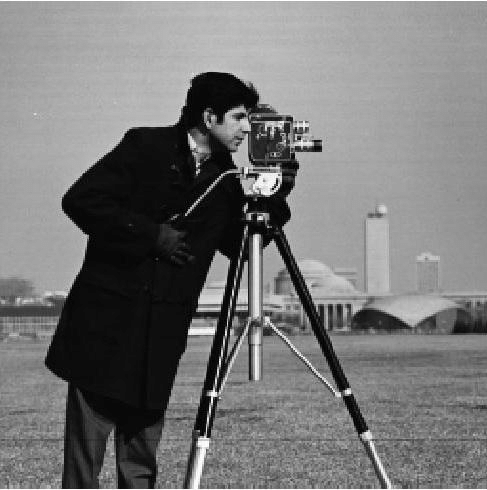

In [1]:
import sys
sys.path.append('../src')

from PIL import Image, ImageOps, ImageFont
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets
from ipywidgets import interactive, HBox, VBox, interact
from IPython.display import clear_output
from image.processing import preprocess_img, DITHER_MODES

IMG_PATH = "../imgs/cameraman.png"
orig_img = Image.open(IMG_PATH).convert("RGB")
display(orig_img)

In [2]:
def i_preprocess_img(
        scale_factor=0.5,
        contrast=1.0,
        brightness=1.0,
        sharpness=1.0,
        enhance_edges=0.0,
        quantize_colors=128,
        eq=0.0,
        dither=DITHER_MODES.NONE,
        grayscale=True):
    prep_img = preprocess_img(
        img=orig_img,
        scale_factor=scale_factor,
        contrast=contrast,
        brightness=brightness,
        eq=eq,
        quantize_colors=quantize_colors,
        dither=dither,
        sharpness=sharpness,
        enhance_edges=enhance_edges,
        grayscale=grayscale)
    
    plt.imshow(prep_img, cmap='gray', vmin=0, vmax=255, interpolation='none')
    plt.figure(figsize=(6, 3))
    plt.xticks([x for x in range(0, len(prep_img.histogram()), 50)])
    plt.bar([x for x in range(0, len(prep_img.histogram()))],
            prep_img.histogram())
    plt.grid()
    plt.show()
    return prep_img

interactive_preprocess = interactive(i_preprocess_img,
                                     scale_factor=(0.01, 1, 0.01),
                                     contrast=(0, 2, 0.01),
                                     brightness=(0, 2, 0.01),
                                     sharpness=(0, 2, 0.01),
                                     eq=(0, 1, 0.01),
                                     enhance_edges=(0, 1, 0.01),
                                     quantize_colors=(1, 256, 1),
                                     dither=DITHER_MODES,
                                     grayscale=True)

controls = VBox(interactive_preprocess.children[:-1])
display(HBox((controls, interactive_preprocess.children[-1])))

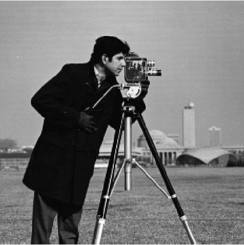

In [3]:
from converters.img_converter import ImgConverter
from palette.symbol2value import get_asciis, symbols_sorted
from rendering.image import render_symbols_img
from rendering.terminal import print_gallery

FONT_PATH = "../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 16
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
SYMBOLS = symbols_sorted(get_asciis(), FONT)
MAX_WIDTH = 80
MAX_HEIGHT = 24

prep_img = interactive_preprocess.result
display(prep_img)



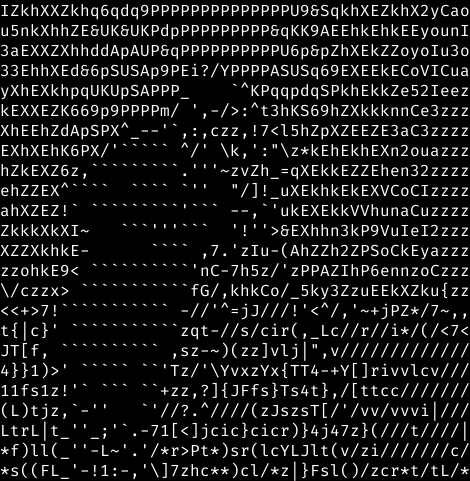

-----------------------------------------------------
 | IZkhXXZkhq6qdq9PPPPPPPPPPPPPPU9&SqkhXEZkhX2yCao | 
 | u5nkXhhZE&UK&UKPdpPPPPPPPPP&qKK9AEEhkEhkEEyounI | 
 | 3aEXXZXhhddApAUP&qPPPPPPPPPPU6p&pZhXEkZZoyoIu3o | 
 | 33EhhXEd&6pSUSAp9PEi?/YPPPPASUSq69EXEEkECoVICua | 
 | yXhEXkhpqUKUpSAPPP_    `^KPqqpdqSPkhEkkZe52Ieez | 
 | kEXXEZK669p9PPPPm/ ',-/>:^t3hKS69hZXkkknnCe3zzz | 
 | XhEEhZdApSPX^_--'`,:,czz,!7<l5hZpXZEEZE3aC3zzzz | 
 | EXhXEhK6PX/'````` ^/' \k,':"\z*kEhEkhEXn2ouazzz | 
 | hZkEXZ6z,`````````.'''~zvZh_=qXEkkEZZEhen32zzzz | 
 | ehZZEX^````  ```` `''  "/]!_uXEkhkEkEXVCoCIzzzz | 
 | ahXZEZ!` `````````'``` --,`'ukEXEkkVVhunaCuzzzz | 
 | ZkkkXkXI~   ```'''```  '!''>&EXhhn3kP9VuIeI2zzz | 
 | XZZXkhkE-      ```` ,7.'zIu-(AhZZh2ZPSoCkEyazzz | 
 | zzohkE9< ``````````'nC-7h5z/'zPPAZIhP6ennzoCzzz | 
 | \/czzx> ```````````fG/,khkCo/_5ky3ZzuEEkXZku{zz | 
 | <<+>7!``````````` -//'^=jJ///!'<^/,'~+jPZ*/7~,, | 
 | t{|c}' ```````````zqt-//s/cir(,_Lc//r//i*/(/<7< | 
 | JT[f, `````````` ,sz-~)(z

In [4]:
from converters.tile.bin_1d import Tile2Symb1dBin
converter = Tile2Symb1dBin(symbols=SYMBOLS,
                           font=FONT,
                           bins=24)

res_arr = ImgConverter(converter).img2symbols(prep_img, max_cols=MAX_WIDTH, max_lines=MAX_HEIGHT)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

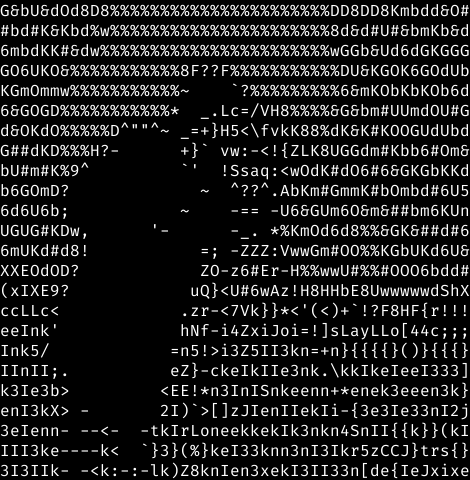

-----------------------------------------------------
 | G&bU&dOd8D8%%%%%%%%%%%%%%%%%%%%%%DD8DD8Kmbdd&O# | 
 | #bd#K&Kbd%w%%%%%%%%%%%%%%%%%%%%%%8d&d#U#&bmKb&d | 
 | 6mbdKK#&dw%%%%%%%%%%%%%%%%%%%%%%%wGGb&Ud6dGKGGG | 
 | GO6UKO&%%%%%%%%%%%8F??F%%%%%%%%%%%DU&KGOK6GOdUb | 
 | KGmOmmw%%%%%%%%%%%~    `?%%%%%%%%%6&mKObKbKOb6d | 
 | 6&GOGD%%%%%%%%%%%*  _.Lc=/VH8%%%%&G&bm#UUmdOU#G | 
 | d&OKdO%%%%%D^""^~ _=+}H5<\fvkK88%dK&K#KOOGUdUbd | 
 | G##dKD%%%H?-      +}` vw:-<!{ZLK8UGGdm#Kbb6#Om& | 
 | bU#m#K%9^         `'  !Ssaq:<wOdK#dO6#6&GKGbKKd | 
 | b6GOmD?             ~  ^??^.AbKm#GmmK#bOmbd#6U5 | 
 | 6d6U6b;           ~    -== -U6&GUm6O&m&##bm6KUn | 
 | UGUG#KDw,      '-      -_. *%KmOd6d8%%&GK&##d#6 | 
 | 6mUKd#d8!           =; -ZZZ:VwwGm#OO%%KGbUKd6U& | 
 | XXEOdOD?            ZO-z6#Er-H%%wwU#%%#OOO6bdd# | 
 | (xIXE9?            uQ}<U#6wAz!H8HHbE8UwwwwwdShX | 
 | ccLLc<            .zr-<7Vk}}*<'(<)+`!?F8HF{r!!! | 
 | eeInk'            hNf-i4ZxiJoi=!]sLayLLo[44c;;; | 
 | Ink5/            =n5!>i3Z

In [5]:
from converters.tile.bin_2d import Tile2Symb2dBin
converter = Tile2Symb2dBin(symbols=SYMBOLS,
                           font=FONT)

res_arr = ImgConverter(converter).img2symbols(prep_img, max_cols=MAX_WIDTH, max_lines=MAX_HEIGHT)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

d:\CS Projects\python-playground\python-ascii-art\notebooks\../src\converters\tile\nearest.py:39: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


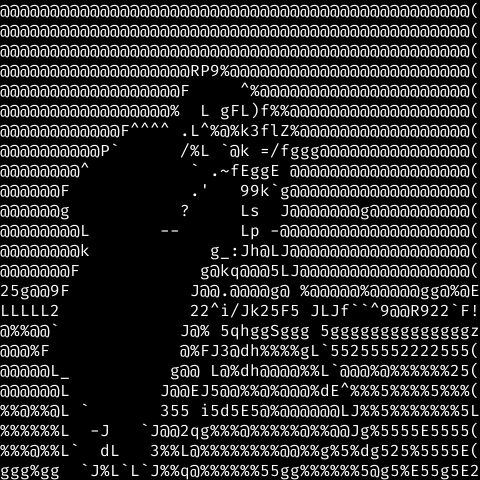

------------------------------------------------------
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@@RP9%@@@@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@@F     ^%@@@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@@@@@@%  L gFL)f%%@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@@@F^^^^ .L^%@%k3flZ%@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@@@P`      /%L `@k =/fggg@@@@@@@@@@@@@@@( | 
 | @@@@@@@@^          ` .~fEggE @@@@@@@@@@@@@@@@@@( | 
 | @@@@@@F            .'   99k`g@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@g           ?     Ls  J@@@@@@@g@@@@@@@@@@( | 
 | @@@@@@@@L       --      Lp -@@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@@k            g_:Jh@LJ@@@@@@@@@@@@@@@@@@( | 
 | @@@@@@@F            g@kq@@@5LJ@@@@@@@@@@@@@@@@@( | 
 | 25g@@9F            J@@.@@@@g@ %@@@@@%@@@@@gg@%@E | 
 | LLLLL2             22^i/Jk25F5 JLJf``^9@@R922`F! | 
 | @%%@@`            J@% 5qhggSggg 5ggggggggggggggz | 
 | @@@%F  

In [6]:
from converters.tile.nearest import Tile2SymbNearest
converter = Tile2SymbNearest(symbols=SYMBOLS,
                             font=FONT)

res_arr = ImgConverter(converter).img2symbols(prep_img, (3, 6), MAX_WIDTH, MAX_HEIGHT)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

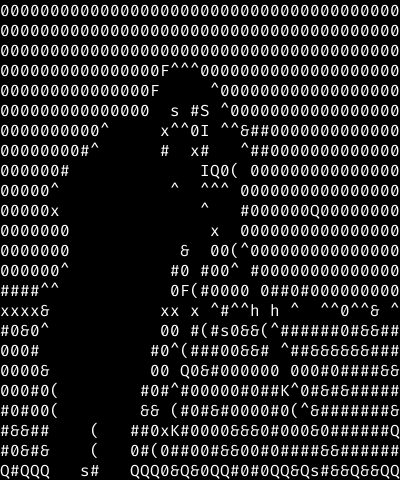

----------------------------------------------
 | 0000000000000000000000000000000000000000 | 
 | 0000000000000000000000000000000000000000 | 
 | 0000000000000000000000000000000000000000 | 
 | 0000000000000000F^^^00000000000000000000 | 
 | 000000000000000F     ^000000000000000000 | 
 | 000000000000000  s #S ^00000000000000000 | 
 | 0000000000^     x^^0I ^^&##0000000000000 | 
 | 00000000#^      #  x#   ^##0000000000000 | 
 | 000000#             IQ0( 000000000000000 | 
 | 00000^           ^  ^^^ 0000000000000000 | 
 | 00000x              ^   #000000Q00000000 | 
 | 0000000              x  0000000000000000 | 
 | 0000000           &  00(^000000000000000 | 
 | 000000^          #0 #00^ #00000000000000 | 
 | ####^^           0F(#0000 0##0#000000000 | 
 | xxxx&           xx x ^#^^h h ^  ^^0^^& ^ | 
 | #0&0^           00 #(#s0&&(^######0#&&## | 
 | 000#           #0^(###00&&# ^##&&&&&&### | 
 | 0000&          00 Q0&#000000 000#0####&& | 
 | 000#0(        #0#^#00000#0##K^0#&#&##### | 
 | #0#00(    

In [7]:
from converters.line_heuristics.greedy import GreedyLineSearch
converter = GreedyLineSearch(symbols=SYMBOLS[::5],
                             font=FONT)

res_arr = ImgConverter(converter).img2symbols(prep_img, (3, 6), MAX_WIDTH, MAX_HEIGHT)
display(render_symbols_img(res_arr, FONT))
print_gallery([res_arr], 1)

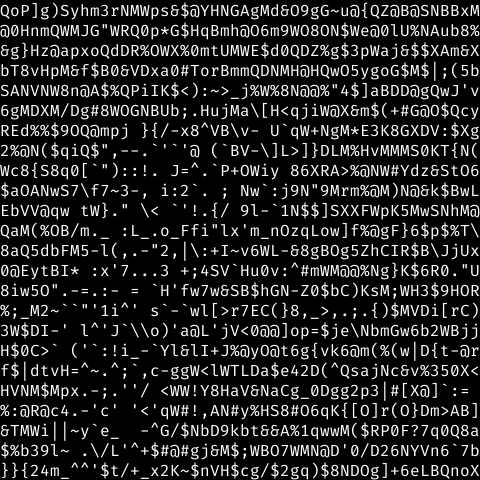

------------------------------------------------------
 | QoP]g)Syhm3rNMWps&$@YHNGAgMd&O9gG~u@{QZ@B@SNBBxM | 
 | @0HnmQWMJG"WRQ0p*G$HqBmh@O6m9WO8ON$We@0lU%NAub8% | 
 | &g}Hz@apxoQdDR%OWX%0mtUMWE$d0QDZ%g$3pWaj&$$XAm&X | 
 | bT8vHpM&f$B0&VDxa0#TorBmmQDNMH@HQwO5ygoG$M$|;(5b | 
 | SANVNW8n@A$%QPiIK$<):~>_j%W%8N@@%"4$]aBDD@gQwJ'v | 
 | 6gMDXM/Dg#8WOGNBUb;.HujMa\[H<qjiW@X&m$(+#G@O$Qcy | 
 | REd%%$9OQ@mpj }{/-x8^VB\v- U`qW+NgM*E3K8GXDV:$Xg | 
 | 2%@N($qiQ$",--.`'`'@ (`BV-\]L>]}DLM%HvMMMS0KT{N( | 
 | Wc8{S8q0[`")::!. J=^.`P+OWiy 86XRA>%@NW#Ydz&StO6 | 
 | $aOANwS7\f7~3-, i:2`. ; Nw`:j9N"9Mrm%@M)N@&k$BwL | 
 | EbVV@qw tW}." \< `'!.{/ 9l-`1N$$]SXXFWpK5MwSNhM@ | 
 | QaM(%OB/m._ :L_.o_Ffi"lx'm_nOzqLow]f%@gF}6$p$%T\ | 
 | 8aQ5dbFM5-l(,.-"2,|\:+I~v6WL-&8gBOg5ZhCIR$B\JjUx | 
 | 0@EytBI* :x'7...3 +;4SV`Hu0v:^#mWM@@%Ng}K$6R0."U | 
 | 8iw5O".-=.:- = `H'fw7w&SB$hGN-Z0$bC)KsM;WH3$9HOR | 
 | %;_M2~``"'1i^' s`-`wl[>r7EC(}8,_>,.;.{)$MVDi[rC) | 
 | 3W$DI-' l^'J`\\o)'a@L'jV<0@@]op=$je\NbmGw6b2WBjj | 
 | H$0C>` 

In [9]:
from converters.line_heuristics.harmony_search import HarmonyLineSearch
converter = HarmonyLineSearch(symbols=SYMBOLS,
                              font=FONT,
                              pop_count=20,
                              generations=20)

img_converter_gen = ImgConverter(converter).img2symbols_lazy(prep_img,
                                                             max_cols=MAX_WIDTH,
                                                             max_lines=MAX_HEIGHT,
                                                             gens_per_step=5)

for res_arr in img_converter_gen:
    clear_output()
    display(render_symbols_img(res_arr, FONT))
    print_gallery([res_arr], 1)